<div align="right">iX Program 2025 | Data Science | Week 1 | Day 2 | NB1 </div>

# Importing Data into Python 

## Notebook objectives
By the end of this notebook, you will be expected to:

> - Import various types of data (delimited text, JSON, and SQL) into Python, using the Pandas
> - Establish database connections and construct SQL queries to extract relevant data
> - Retrieve data programmatically using APIs
> - Web scraping basics
 
## List of exercises
> - **Exercise 1:** Importing data in JSON files (5)
> - **Exercise 2:** Creating and querying SQL tables using `sqlite3` with Python  (20)
> - **Exercise 3:** Using APIs to access data (5)
> - **Exercise 4:** Getting data using web scraping (10)

# Importing Data 
Input data that is typically stored in either files or databases. Making this data accessible for analysis in Python is an important aspect of the Data Science workflow. In this notebook, we will explore various approaches to access and make data available for analysis in Python from different source systems, including relational databases and the worldwide web.

## Loading CSV files
A flat file is a simple, plain text file that stores data in a structured format, typically as rows and columns. Each line in the file represents a single record, and fields (or columns) within each record are usually separated by a delimiter such as a comma (CSV), tab (TSV), or another character.

**Common Examples:**
- `.csv` (Comma-Separated Values)

- `.tsv` (Tab-Separated Values)

- `.txt` files with custom delimiters

> CSV files include both a delimiter, separating data fields, and an optional enclosing character. While a comma ( , ) is usually used as a delimiter (hence the term CSV, which is the abbreviation for comma-separated values), other common delimiters include a pipe ( | ), a tab ( \t ), or any single value character (e.g., : ). An enclosing character occurs at the beginning and the end of a value. It is sometimes called a quote character (because it is usually double quotation marks), but other characters can be used.

**Key Characteristics:**
- **Human-readable**: Can be opened and read in any text editor.

- **No internal hierarchy or relationships**: Unlike relational databases, flat files don't contain links between tables.

- **Lightweight and easy to share**, but not ideal for handling very large datasets or complex queries.


Flat files are commonly used for data exchange between systems or for quick data storage and retrieval in data science workflows. In the first example, a CSV file of the widely used iris dataset that contains five columns and three rows is loaded. 
For illustration purposes only, let’s first see what the file looks like on disk. If you are not familiar with command line utilities, the next command does the following. Firstly, the exclamation tells the interpreter to invoke executable statement in the system shell. The ```head``` command reads one or more files, in this case "iris.csv", and prints the specified first number of lines from the target file to standard output.

In [0]:
# Read the file "workbook.csv" and print the first 6 lines.
!head -6 iris.csv

sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa


In [0]:
# Find how many lines while we at it!
!wc -l iris.csv

In [0]:
# We can also print the last 10 lines.
!tail -5 iris.csv

We can see that the file is indeed a CSV file with a "," delimiter separating the five fields. Next, we use the `pandas`'s `read_csv` method to read the file. By default, `read_csv` assumes the delimiter is a comma if not specified. If the delimiter was, for example, a semi-colon, we'd need to explicitly tell `pandas` to use ";" as the separator. 

Let's now load this into our workspace and make it available for analysis. Load the `pandas` module and assign it an alias in the local namespace for easy reference.

In [0]:
import pandas as pd

In [0]:
# load the iris.csv and assign to a variable df (short for dataframe).
# since the file has a header, read_csv needs to know to correctly process the file's contents 
df = pd.read_csv('iris.csv', sep =",", header=0)

# print the first few lines
df.head()


In [0]:
# print the total number of rows
df.shape[0]

In [0]:
# print the last few lines
df.tail()

<br>
<div class="alert alert-info">
<b style="font-size: 20px">Think about it:</b>
    
Compare and contrast the behaviors of working with the command shell and the `pandas` library for the tasks above.
</div>

Notice that `pandas` automatically includes indexes to label the rows and columns. In particular, the rows are indexed by a sequence of labels [0, 1, 149]. In the example, we specified that the file has a header in the very first line, this is used as such.

### JSON
JavaScript Object Notation (JSON) is a lightweight data-interchange format that is easy to read and write for humans, and easy to parse and generate for computers. The JSON format is often used for serializing and transmitting structured data over a network connection. It is used primarily to transmit data between a server and web application, serving as an alternative to XML (EXtensible Markup Language). Twitter stores data in JSON. Interestingly, the Jupyter Notebook that you are working in uses a JSON format to store its data. In general, you can think of the JSON format as a store of data whose structure you do not know at the time of capture, (i.e., unstructured data).

JSON is built on two structures:
- **A collection of name or value pairs**: In various languages, this is realized as an object, record, struct, dictionary, hash table, keyed list, or associative array.
- **An ordered list of values**: In most languages, this is realized as an array, vector, list, or sequence.

You can read more about the [Python encoder and decoder](https://docs.python.org/3/library/json.html) in the Python documentation.

The following example creates a JSON string, and demonstrates how Pandas can be used to read the string.

In [0]:
# Create a JSON string that captures details of a John Smith from New York.
jsonStr = (""" {
     "firstName": "John",
     "lastName": "Smith",
     "address": {
         "streetAddress": "21 2nd Street",
         "city": "New York", 
         "state": "NY",
         "postalCode": 10021 
     }, \
     "phoneNumbers": [ 
         "212 555-4321", 
         "646 555-7654" 
     ]
 }"""
)

Your JSON string is technically a single expression spanning multiple lines in the cell. Let’s display the JSON string object you have just created. First import the `json` module, and then load and print the JSON string.

In [0]:
import json
print(json.dumps(json.loads(jsonStr), indent=4, sort_keys=True))

<br>
<div class="alert alert-info">
<b>Think about it:</b>
    
Can you decipher the above expression in the call to `print()`?
</div>

`Pandas` has a ```read_json()``` method that reads JSON objects into a `Pandas` `Series` or `DataFrame` object.
> **Note**: You can access the docstring for any of these `Pandas` objects by appending a question mark to the object or method name. Thus, “```pd.read_json?```” will display the docstring containing more details on what the read_json method does and how it is to be used.

<br>
<div class="alert alert-success">
<b>Try it yourself:</b>
</div>

In [0]:
pd.read_json?

In [0]:
# Read JSON-formatted data using pandas and print the dataframe.
# First, to read from a literal string, we'll wrap it in a 'StringIO' object. Don't worry about the details. 
from io import StringIO
df_json = pd.read_json(StringIO(jsonStr), orient='columns', typ='series')
print(df_json)

<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Exercise 1: Loading Weather Data Using read_json()  </b>
</div>

### Objective:
Learn how to load JSON data into a Pandas DataFrame using the `read_json()` function.

### Dataset:
We will use sample weather data provided by Tablab: URL: [https://www.tablab.app/json/sample](https://www.tablab.app/json/sample)


### Instructions:
- Import the necessary libraries.

- Download the weather data from the URL above to your machine.

- Use `pandas.read_json("weather.json",lines=True)` to load the downloaded data, and assign it to a dataframe `weather_df`.

- Display the first few rows to inspect the structure using `head()`

- Print out the column names and the data types of each column using DataFrame methods `.columns()` and `.dtypes()`

<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

In [0]:

import pandas as pd

# Load the JSON data into a DataFrame
weather_df = pd.read_json("weather.json", lines=True)

# Display the first few rows
display(weather_df.head())

# Print column names

print(weather_df.columns)

# Print data types
print(weather_df.dtypes)

MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
8.0,24.3,0.0,3.4,6.3,NW,30,SW,NW,6,20,68,29,1019.7,1015.0,7,7,14.4,23.6,No,3.6,Yes
14.0,26.9,3.6,4.4,9.7,ENE,39,E,W,4,17,80,36,1012.4,1008.4,5,3,17.5,25.7,Yes,3.6,Yes
13.7,23.4,3.6,5.8,3.3,NW,85,N,NNE,6,6,82,69,1009.5,1007.2,8,7,15.4,20.2,Yes,39.8,Yes
13.3,15.5,39.8,7.2,9.1,NW,54,WNW,W,30,24,62,56,1005.5,1007.0,2,7,13.5,14.1,Yes,2.8,Yes
7.6,16.1,2.8,5.6,10.6,SSE,50,SSE,ESE,20,28,68,49,1018.3,1018.5,7,7,11.1,15.4,Yes,0.0,No


Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine          object
WindGustDir       object
WindGustSpeed     object
WindDir9am        object
WindDir3pm        object
WindSpeed9am      object
WindSpeed3pm       int64
Humidity9am        int64
Humidity3pm        int64
Pressure9am      float64
Pressure3pm      float64
Cloud9am           int64
Cloud3pm           int64
Temp9am          float64
Temp3pm          float64
RainToday         object
RISK_MM          float64
RainTomorrow      object
dtype: object


<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 1 End.</b>
</div>

## Working with Relational Databases with SQL

SQL-based relational databases remain the most common systems used as data stores. Accessing data from a database like SQL is not only more efficient, it also allows you to subset and import only the parts of the data that you need. In Python, the SQLite3 module provides a straightforward interface for interacting with SQLite databases. [SQLite](https://docs.python.org/3/library/sqlite3.html?highlight=sqlite#module-sqlite3) is a lightweight, disk-based database that does not require a separate server process. Other databases would require different libraries and connection strings, but the underlying principles are very similar to the example demonstrated below.

### Using SQLite3
#### 1. Create a connection to the database
First, we need to create a new database and open a database connection to allow `sqlite3` to work with it. `sqlite3.connect()` creates a connection to the database "ixperience_ds.db" in the current working directory, implicitly creating it if it does not exist:

In [0]:
import sqlite3

# Connect to (or create if it doesn't exist) a SQLite database
conn = sqlite3.connect("ixperience_ds.db")

You can verify that a file "ixperience_ds.db" has been created in the working directory. Let's do that using a command shell calls:

In [0]:
!ls -al | grep 'ixperi'

#### 2. Create a database cursor
The returned Connection object `conn` represents the connection to the on-disk database.

In order to execute SQL statements and fetch results from SQL queries, we will need to use a database cursor. Call conn.cursor() to create the Cursor:

In [0]:
cursor = conn.cursor()

#### 3. Create a TABLE in db
Create a sample table "students" with columns for `id`, `name`, `age` and `grade`. We have specified the data types for each of the columns. However, we could just have used column names in the table declaration – thanks to the flexible typing feature of SQLite, specifying the data types is optional. Note that we have also specified the id as a PRIMARY KEY for the table. A primary key in a database table is a column or a set of columns that uniquely identifies each row in the table.

**Key Characteristics of a primary key:**
**Uniqueness:** No two rows can have the same primary key value.

**Non-null:** A primary key column cannot contain NULL values.

**Immutable:** Once assigned, primary key values should generally not change.

In [0]:
# Create a sample table for demonstration
cursor.execute("""
    CREATE TABLE IF NOT EXISTS students (
        id INTEGER PRIMARY KEY,
        name TEXT,
        age INTEGER,
        grade REAL
    )
""")

#### 4. Inserting data into the TABLE
Now, add three rows of data supplied as SQL literals by executing an INSERT statement, by calling `executemany` (which has the same functionality as `execute` above but more efficient for batch inserts.

The INSERT statement implicitly opens a transaction, which needs to be committed before changes are saved in the database. Call `conn.commit()` on the connection object to commit the transaction:

Notice that `? ` placeholders are used to bind data to the query. The [use of placeholders is recommended](https://docs.python.org/3/library/sqlite3.html#sqlite3-placeholders)  (instead of string formatting) to bind Python values to SQL statements. 

In [0]:
# Insert sample data
cursor.executemany("""
    INSERT INTO students (name, age, grade) VALUES (?, ?, ?)
""", [
    ("Alice", 20, 85.5),
    ("Bob", 22, 78.0),
    ("Charlie", 21, 92.3)
])

conn.commit()
print("Database setup complete!")

#### 5. Running SQL queries against connection

Let's verify that the data was inserted correctly by executing a SELECT query, and return the result in a tuple object.

In [0]:
cursor.execute("SELECT * FROM students")
rows = cursor.fetchall()
for row in rows:
    print(row)


We can perform more complex SQL queries, return the result in tuple as above.

In [0]:
cursor.execute("SELECT name, grade FROM students WHERE grade > 80")
high_achievers = cursor.fetchall()
print("High Achievers:", high_achievers)

#### 6. Closing a connection

We need to make sure we close any db connection opened for table creation, table inserts, or queries. This is important for many reasons including:

- **Free up resources:** Database connections consume system and database server resources (like memory and file descriptors). If not closed, these resources can accumulate, potentially leading to connection exhaustion and degraded performance.

- **Avoid data corruption or loss:** Closing a connection properly ensures that any pending transactions are committed or rolled back, avoiding partial writes or inconsistencies in the database.

- **Prevent connection leaks:** If a program repeatedly opens connections without closing them, it can lead to a connection leak, where the system eventually runs out of available connections, causing errors or crashing the application.

- **Better concurrency and scaling:** In multi-user or multi-threaded environments, closing unused connections ensures that other users or processes can access the database efficiently.

In [0]:
conn.close()

> **Best Practice:**
> 
> Use context managers (`with` statements in Python) to automatically handle closing:
>
```python
import sqlite3

with sqlite3.connect("example.db") as conn:
    cursor = conn.cursor()
    # Do something with the database
# Connection is automatically closed here

<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 2: Querying the Chinook SQLite Database in Python </b>
</div>

### Objective: 
- Learn how to connect to a SQLite database using Python, execute SQL queries, and explore results using Pandas.

### Dataset: 
- Download the Chinook database: [Chinook_Sqlite.sqlite](https://github.com/lerocha/chinook-database/blob/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite)

- Place the `.sqlite` file in your working directory.

### Instructions:
1. Import required Libraries
2. Connect to the Chinook Database
3. Write and run the following SQL queries:

   3.1 Retrieve the top 5 customers by total spending

   3.2 Find the 3rd most popular music genre (by track count)

   3.3 Query all albums by AC/DC
   
   3.4 List the top 5 most purchased tracks
   
   3.5 Count how many customers are from each country.
   
   3.6 List employees who report to a manager (i.e., have a non-null ReportsTo field).
   
   3.7 Find the total sales (Total) for each customer from the invoices table.
   
4. Close the connection

<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

In [0]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("Chinook_Sqlite.sqlite")

# 3.1 Retrieve the top 5 customers by total spending
q1 = """
SELECT c.CustomerId, c.FirstName, c.LastName, SUM(i.Total) as TotalSpending
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY TotalSpending DESC
LIMIT 5
"""
df1 = pd.read_sql_query(q1, conn)
display(df1)
#Find the 3rd most popular music genre (by track count)
q2 = """
SELECT GenreId, Name, COUNT(*) as TrackCount
FROM Track
JOIN Genre USING (GenreId)
GROUP BY GenreId
ORDER BY TrackCount DESC
LIMIT 1 OFFSET 2
"""
df2 = pd.read_sql_query(q2, conn)
display(df2)
# 3.3 Query all albums by AC/DC
q3 = """
SELECT Album.AlbumId, Album.Title
FROM Album
JOIN Artist ON Album.ArtistId = Artist.ArtistId
WHERE Artist.Name = 'AC/DC'
"""
df3 = pd.read_sql_query(q3, conn)

display(df3)

# pt 4 Listing top 5
q4 = """
SELECT t.TrackId, t.Name, COUNT(il.InvoiceLineId) as PurchaseCount
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
GROUP BY t.TrackId
ORDER BY PurchaseCount DESC
LIMIT 5
"""
df4 = pd.read_sql_query(q4, conn)
display(df4)

# 3.5 Count how many customers are from each country
q5 = """
SELECT Country, COUNT(*) as CustomerCount
FROM Customer
GROUP BY Country
ORDER BY CustomerCount DESC
"""
df5 = pd.read_sql_query(q5, conn)
display(df5)

# 3.6 List employees who report to a manager (i.e., have a non-null ReportsTo field)
q6 = """
SELECT EmployeeId, FirstName, LastName, ReportsTo
FROM Employee
WHERE ReportsTo IS NOT NULL
"""
df6 = pd.read_sql_query(q6, conn)
display(df6)

# 3.7 Find the total sales (Total) for each customer from the invoices table
q7 = """
SELECT CustomerId, SUM(Total) as TotalSales
FROM Invoice
GROUP BY CustomerId
ORDER BY TotalSales DESC
"""
df7 = pd.read_sql_query(q7, conn)
display(df7)

# Close the connection
conn.close()

<br>
<div class="alert alert-info">
<b style="font-size: 25px">Exercise 2 End.</b>
</div>

## Using APIs to Access Data
In data science, APIs (Application Programming Interfaces) are a common way to programmatically access up-to-date, external data from sources like financial markets, government databases, and online platforms.

**yfinance:**
yfinance is a Python library designed specifically for downloading historical market data from Yahoo Finance. It is often used under the hood by pandas-datareader when the "yahoo" source is specified, but it can also be used directly for more advanced features.

**Strengths:** Robust, supports detailed stock data (price, volume, splits, dividends), and works well for historical and near real-time data.

> **Note:**
> Yahoo's official finance API was deprecated, but `yfinance` scrapes data from the site in a reliable and user-friendly way.

In [0]:
# !pip install -Uq yfinance

<br>
<div class="alert alert-info">
<b style="font-size: 25px">Exercise 3: Accessing Financial Data Yahoo Finance via API</b>
</div>

### Objective:

Learn how to fetch real-time financial market data using an API and analyze it with Python.

### Description:

This exercise demonstrates how to use the remote data access functionality provided by the `yfinance` library.Your goal is to collect daily data for the S&P 500 index and the Apple, Microsoft, Amazon, and Google stocks, and well as the S&P 500 index for the period 01/01/2021 to 31/12/2021. The tickers to use for these are:
- Apple: AAPL
- Microsoft: MSFT
- Amazon: AMZN
- Google: GOOG
- S&P 500: ^GSPC


### Instructions:
1. Import the `yfinance` library (install if not available)
2. Define time period of interest by setting correspong values for start_date and end_date variables
3. Collect historical data. You can use the following code template:
   
    ```python
    tickers = ['AAPL','AMZN', 'GOOG', 'MSFT', '^GSPC']
    df = yf.download(tickers, start=start_date, end=end_date)
    `
5. Display the top 10 rows
6. Visualise the data
   
Lastly, use the native pandas `plot` method to visualise the time series of the closing stock prices. This method allows you to plot the series of data using a built-in visualisation tool. Plotting the data is an easier way to visualise the performance of each stock as opposed to a DataFrame. In addition, you can easily compare individual stock performance with that of the S&P 500 benchmark.


<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


/local_disk0/.ephemeral_nfs/envs/pythonEnv-5518cd4b-a335-4add-a52c-589cf9e392a1/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[                       0%                       ]/local_disk0/.ephemeral_nfs/envs/pythonEnv-5518cd4b-a335-4add-a52c-589cf9e392a1/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
[*******************   40%                       ]  2 of 5 completed/local_disk0/.ephemeral_nfs/envs/pythonEnv-5518cd4b-a335-4add-a52c-589cf9e392a1/lib/python3.11/site-packages/yfinance/scrapers/history.py:389: FutureWarning: The default dtype for empty Series will be '

"('Close', 'AAPL')","('Close', 'AMZN')","('Close', 'GOOG')","('Close', 'MSFT')","('Close', '^GSPC')","('High', 'AAPL')","('High', 'AMZN')","('High', 'GOOG')","('High', 'MSFT')","('High', '^GSPC')","('Low', 'AAPL')","('Low', 'AMZN')","('Low', 'GOOG')","('Low', 'MSFT')","('Low', '^GSPC')","('Open', 'AAPL')","('Open', 'AMZN')","('Open', 'GOOG')","('Open', 'MSFT')","('Open', '^GSPC')","('Volume', 'AAPL')","('Volume', 'AMZN')","('Volume', 'GOOG')","('Volume', 'MSFT')","('Volume', '^GSPC')"
125.7408447265625,159.3314971923828,85.70833587646484,208.40652465820312,3700.64990234375,129.8217592553949,163.60000610351562,87.315638555267,213.4900752334204,3769.989990234375,123.16597863459702,157.2010040283203,84.6971371007331,205.64933874293737,3662.7099609375,129.73431458165692,163.5,87.16140251606141,213.04011740396882,3764.610107421875,143301900,88228000,38038000,37130100,5015000000
127.29547119140625,160.92550659179688,86.33717346191406,208.60760498046875,3726.860107421875,128.0047841932833,161.16900634765625,86.67192667952663,209.20117488968572,3737.830078125,124.78862009202955,158.2530059814453,85.20125091979266,206.50142734305604,3695.070068359375,125.2355842462787,158.30050659179688,85.5476577295368,207.9948984930746,3698.02001953125,97664900,53110000,22906000,23823000,4591020000
123.0105209350586,156.91900634765625,86.05797576904297,203.19854736328125,3748.139892578125,127.33435496235823,159.87550354003906,86.68829892340156,207.25773679566413,3783.0400390625,122.7967573877346,156.55799865722656,84.25824485610288,202.90176972562557,3705.340087890625,124.0987683518539,157.32400512695312,84.438270161546,203.1219572296807,3712.199951171875,155088000,87896000,52042000,35930700,6064110000
127.20804595947266,158.10800170898438,88.63481903076172,208.98095703125,3803.7900390625,127.89792197499627,160.427001953125,88.69184596189093,209.98618241670528,3811.550048828125,124.2348079857969,157.75,86.14525598682192,204.5962852345555,3764.7099609375,124.72063157172194,157.85000610351562,86.29452791403196,204.91219943951467,3764.7099609375,109578200,70290000,45300000,27694500,5099160000
128.30599975585938,159.13499450683594,89.62468719482422,210.25424194335938,3824.679931640625,128.86955684085643,159.53199768066406,89.75511662694235,211.17330891527592,3826.68994140625,126.53759495540402,157.11000061035156,87.95465167422685,207.7746966889817,3783.60009765625,128.67521556411702,159.0,88.671022238762,209.35432615637777,3815.050048828125,105158200,70754000,41012000,22956200,4773040000
125.32302856445312,155.7104949951172,87.61666870117188,208.21507263183594,3799.610107421875,126.47929089114106,157.81900024414062,88.9851863313301,209.5745145115379,3817.860107421875,124.85664214589357,155.5,87.30919548708157,207.4874737327891,3789.02001953125,125.5270809622862,157.40049743652344,88.57628903059744,209.1532761190525,3803.139892578125,100384500,73668000,24194000,23031300,4465430000
125.14816284179688,156.04150390625,86.61638641357422,205.76425170898438,3801.18994140625,126.01292826031991,157.10699462890625,88.17806619639528,207.84172439484524,3810.780029296875,123.26316489383075,154.3000030517578,85.56303785339858,204.22292456798172,3776.510009765625,124.85666571536174,156.0,86.98188545419609,207.26730569518543,3801.6201171875,91951100,70292000,27140000,23249300,4994950000
127.17891693115234,158.29449462890625,87.00569152832031,207.1140899658203,3809.840087890625,127.72303705735104,159.49749755859375,87.53310739732585,207.51617714350778,3820.9599609375,124.8469692971118,156.10400390625,86.1928610169158,204.80686188159456,3791.5,125.10930339828236,156.4219970703125,86.2211323296926,204.8930348974412,3802.22998046875,88636800,66424000,21882000,20087100,4602510000
125.25502014160156,156.37350463867188,86.30047607421875,203.9356689453125,3795.5400390625,127.2857588427231,158.89999389648438,88.02779564101687,208.1863254557164,3823.60009765625,125.10926419379747,156.0294952392578,85.96423211932873,203.66761084177992,3792.860107421875,127.09143240514113,158.37600

<Axes: title={'center': 'Closing Prices: AAPL, AMZN, GOOG, MSFT, S&P 500 (2021)'}, xlabel='Date'>

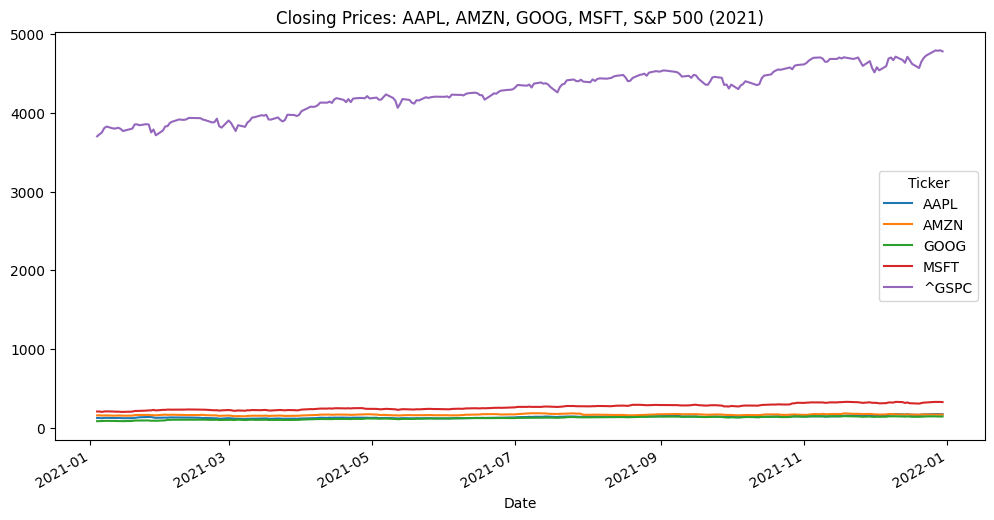

In [0]:
%pip install -Uq yfinance

import yfinance as yf
import pandas as pd

# Define time period
start_date = "2021-01-01"
end_date = "2021-12-31"

# Define tickers
tickers = ['AAPL', 'AMZN', 'GOOG', 'MSFT', '^GSPC']

# Download historical data
df = yf.download(tickers, start=start_date, end=end_date)

# Display top 10 rows
display(df.head(10))

# Visualise closing prices
df['Close'].plot(figsize=(12,6), title="Closing Prices: AAPL, AMZN, GOOG, MSFT, S&P 500 (2021)")

<br>
<div class="alert alert-info">
<b style="font-size: 25px">Exercise 3 End.</b>
</div>

# Web Scraping Demos

- How HTML is structured (tags, classes)

- How to use BeautifulSoup to parse and navigate HTML

- How to extract data with .find_all() and class selectors

- How web scraping simulates accessing real-world data

### Demo: Scrape Product Names from a Mock HTML Page

In [0]:
# Mock HTML content (can simulate a product listing page)
html_doc = """
<html>
<head><title>Mock E-commerce Page</title></head>
<body>
  <div class="product">
    <h2 class="product-name">Wireless Mouse</h2>
    <p class="price">$25</p>
  </div>
  <div class="product">
    <h2 class="product-name">Bluetooth Headphones</h2>
    <p class="price">$59</p>
  </div>
  <div class="product">
    <h2 class="product-name">USB-C Charger</h2>
    <p class="price">$18</p>
  </div>
</body>
</html>
"""

In [0]:
from bs4 import BeautifulSoup

# Parse HTML
soup = BeautifulSoup(html_doc, 'html.parser')

# Find all product blocks
products = soup.find_all('div', class_='product')

# Loop through each product block and extract name and price
print("Product catalog:")
for product in products:
    name = product.find('h2', class_='product-name').text
    price = product.find('p', class_='price').text
    print(f"- {name} | Price: {price}")

### Scrape Book Titles and Prices

In [0]:
import requests


# Target URL (homepage)
url = "https://books.toscrape.com/"

# Fetch page content
response = requests.get(url)
# response.encoding = 'utf-8'  # Fix encoding

soup = BeautifulSoup(response.text, 'html.parser')

# Find all book containers
books = soup.find_all('article', class_='product_pod')

# Extract title and price
print("Books on Homepage:")
for book in books:
    title = book.h3.a['title']
    price = book.find('p', class_='price_color').text
    print(f"- {title} | {price}")

<br>
<div class="alert alert-info">
<b style="font-size: 25px;">Exercise 4: Web Scraping News Headlines Using BeautifulSoup</b>
</div>

**Objective:**

Use Python and `BeautifulSoup` to scrape headlines from a live news website and extract them into a structured format.

**Instructions:**
1. Import Required Libraries (`BeautifulSoup`, `requests`)
2. Choose a Target Site
Use the [BBC News homepage](https://www.bbc.com/news) as the target.

> For educational use only. Avoid scraping aggressively and always check the site’s `robots.txt` and terms of service.

3. Make an HTTP Requests (using `response = requests.get(target_url`
4. Extracts the webpage's HTML as a string via:
   
   `html_content = response.text`
5.  Parse the HTML using BeatifulSoup:
    `soup = BeautifulSoup(html_content, "html.parser")`
6. Extract Headline Titles

   Look for headline tags (e.g., `<h2>` or `<a>` with specific classes — inspect the site in your browser):

   ```python
    headlines = soup.find_all("h2")
    for i, headline in enumerate(headlines[:10], 1):
    print(f"{i}. {headline.text.strip()}")
        
   
7. Questions:
   
   7.1 How many headlines were you able to extract?

   7.2 What other information (e.g., links, timestamps) can you find?

   7.3 Can you export the data to a CSV file using Pandas?


<br>
<div class="alert alert-info">
  <b style="font-size: 25px;">Your Solution Here</b>
</div>

In [0]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Target URL
url = "https://www.bbc.com/news/articles/crkp777llgko"

# Fetch page content
response = requests.get(url)
html_content = response.text

# Parse HTML
soup = BeautifulSoup(html_content, "html.parser")

# Extract headline titles (using <h2> tags)
headlines = soup.find_all("h2")
headline_data = []

for headline in headlines:
    title = headline.text.strip()
    # Try to find a link if available
    parent_a = headline.find_parent("a")
    link = parent_a['href'] if parent_a and parent_a.has_attr('href') else None
    # Try to find a timestamp if available
    timestamp = None
    time_tag = headline.find_next("time")
    if time_tag and time_tag.has_attr('datetime'):
        timestamp = time_tag['datetime']
    headline_data.append({"title": title, "link": link, "timestamp": timestamp})

# Display first 10 headlines
for i, item in enumerate(headline_data[:10], 1):
    print(f"{i}. {item['title']}")





In [0]:
# 7.1 How many headlines were you able to extract?
print(len(headline_data))

# 7.2 What other information (e.g., links, timestamps) can you find?
# images, embedded links, logos

In [0]:
# 7.3 Can you export the data to a CSV file using Pandas?
df = pd.DataFrame(headline_data)
df.to_csv("bbc_headlines.csv", index=False)

<br>
<div class="alert alert-info">
<b style="font-size: 25px">Exercise 4 End.</b>
</div>

<br>
<div class="alert alert-warning">
<b style="font-size: 25px;"> Submit your notebook</b><br>

Please make sure that you:
- Perform a final "Save and Checkpoint";
- Download a copy of the notebook in ".ipynb" format to your local machine using "File --> Download." Ensure the downloaded file has an extension ".ipynb".
- Rename the filename by prefixing with your name and surname, i.e. '*Your_Name_iX_DataScience_Bootcamp_DataIngestion_NB1.ipynb*' 
- Submit a copy of this file by Email to your Teaching Assistant.